# Meteo: Shot-wave incoming radiation (SW_IN) (2006-2024)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Variable

In [1]:
varname = 'SW_IN_T1_47_1_gfXG'
var = "SW_IN"  # Name shown in plots
units = r"($\mathrm{W\ m^{-2}}$)"

# Imports

In [2]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import diive as dv
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.bar import LongtermAnomaliesYear

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


# Load data

In [3]:
SOURCEDIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"
FILENAME = r"01_METEO_SW_IN_GAPFILLED_2004-2025.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
keeplocs = (df.index.year >= 2004) & (df.index.year <= 2025)
df = df[keeplocs].copy()
df

Loaded .parquet file ..\10_METEO\02_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.050 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,0.0
2004-01-01 00:45:00,0.0
2004-01-01 01:15:00,0.0
2004-01-01 01:45:00,0.0
2004-01-01 02:15:00,0.0
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


In [4]:
series = df[varname].copy()
series

TIMESTAMP_MIDDLE
2004-01-01 00:15:00    0.0
2004-01-01 00:45:00    0.0
2004-01-01 01:15:00    0.0
2004-01-01 01:45:00    0.0
2004-01-01 02:15:00    0.0
                      ... 
2025-12-31 21:45:00    0.0
2025-12-31 22:15:00    0.0
2025-12-31 22:45:00    0.0
2025-12-31 23:15:00    0.0
2025-12-31 23:45:00    0.0
Freq: 30min, Name: SW_IN_T1_47_1_gfXG, Length: 385728, dtype: float64

In [5]:
xlabel = f"{var} ({units})"
xlim = [series.min(), series.max()]

</br>

# Stats

## Overall mean

In [6]:
_yearly_avg = series.resample('YE').mean()
_overall_mean = _yearly_avg.mean()
_overall_sd = _yearly_avg.std()
print(f"Overall mean: {_overall_mean} +/- {_overall_sd}")

Overall mean: 144.935524928689 +/- 8.003137391079289


## Yearly means

In [7]:
series.resample('YE').mean()

TIMESTAMP_MIDDLE
2004-12-31    137.045214
2005-12-31    137.436372
2006-12-31    136.215301
2007-12-31    142.079029
2008-12-31    137.115026
2009-12-31    142.229589
2010-12-31    133.375169
2011-12-31    150.179649
2012-12-31    139.322202
2013-12-31    137.956417
2014-12-31    145.084413
2015-12-31    156.036396
2016-12-31    143.684005
2017-12-31    153.632975
2018-12-31    152.523451
2019-12-31    151.406077
2020-12-31    155.995946
2021-12-31    146.991261
2022-12-31    161.038052
2023-12-31    146.304983
2024-12-31    133.693489
2025-12-31    149.236531
Freq: YE-DEC, Name: SW_IN_T1_47_1_gfXG, dtype: float64

## Monthly averages

In [8]:
seriesdf = pd.DataFrame(series)
seriesdf['MONTH'] = seriesdf.index.month
seriesdf['YEAR'] = seriesdf.index.year
monthly_avg = seriesdf.groupby(['YEAR', 'MONTH'])[varname].mean().unstack()
monthly_avg

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2004,32.921055,91.459470,131.724653,191.382129,217.757969,238.836970,236.431565,187.842990,158.545562,80.624679,44.245848,32.565102
2005,54.392203,73.769130,145.221577,154.932985,204.441865,274.394129,220.896911,182.988497,154.428353,92.702592,59.531986,28.392369
2006,51.132396,59.207097,107.056757,163.034695,189.134353,268.828747,284.631757,146.801203,156.113431,99.957259,64.139708,40.553657
2007,40.044657,77.521117,136.591853,254.360718,212.130247,227.621074,220.056369,182.625512,163.054023,104.118621,51.774146,32.947437
2008,48.432020,106.768778,117.782596,139.180475,241.819673,228.358733,244.397586,203.622878,139.554537,90.507985,53.925797,29.476573
2009,39.926691,77.234744,106.346594,201.152940,229.258268,253.325577,227.394944,234.365153,160.840823,95.777404,48.377128,29.522343
2010,37.316656,67.652097,126.240922,213.493498,161.359556,223.413995,256.899739,176.884423,167.513280,90.580334,48.001188,28.622214
2011,40.118384,76.240517,143.854512,239.341207,268.683386,212.808491,230.237729,236.790063,170.346927,96.294837,55.795283,26.991417
2012,34.980938,98.012108,174.306218,146.527693,243.805827,233.294258,226.371643,213.922834,149.273764,73.690183,42.139510,33.326164


</br>

# Heatmap plots

## Half-hourly

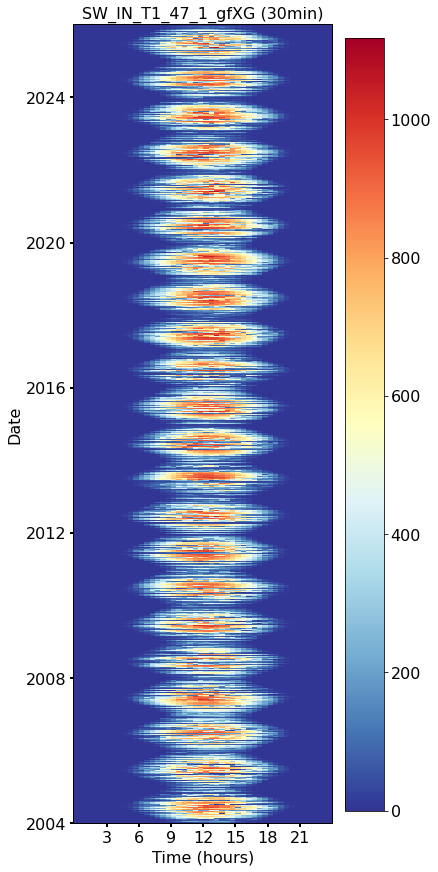

In [9]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
dv.heatmapdatetime(series=series, ax=axs, cb_digits_after_comma=0).plot()

## Monthly

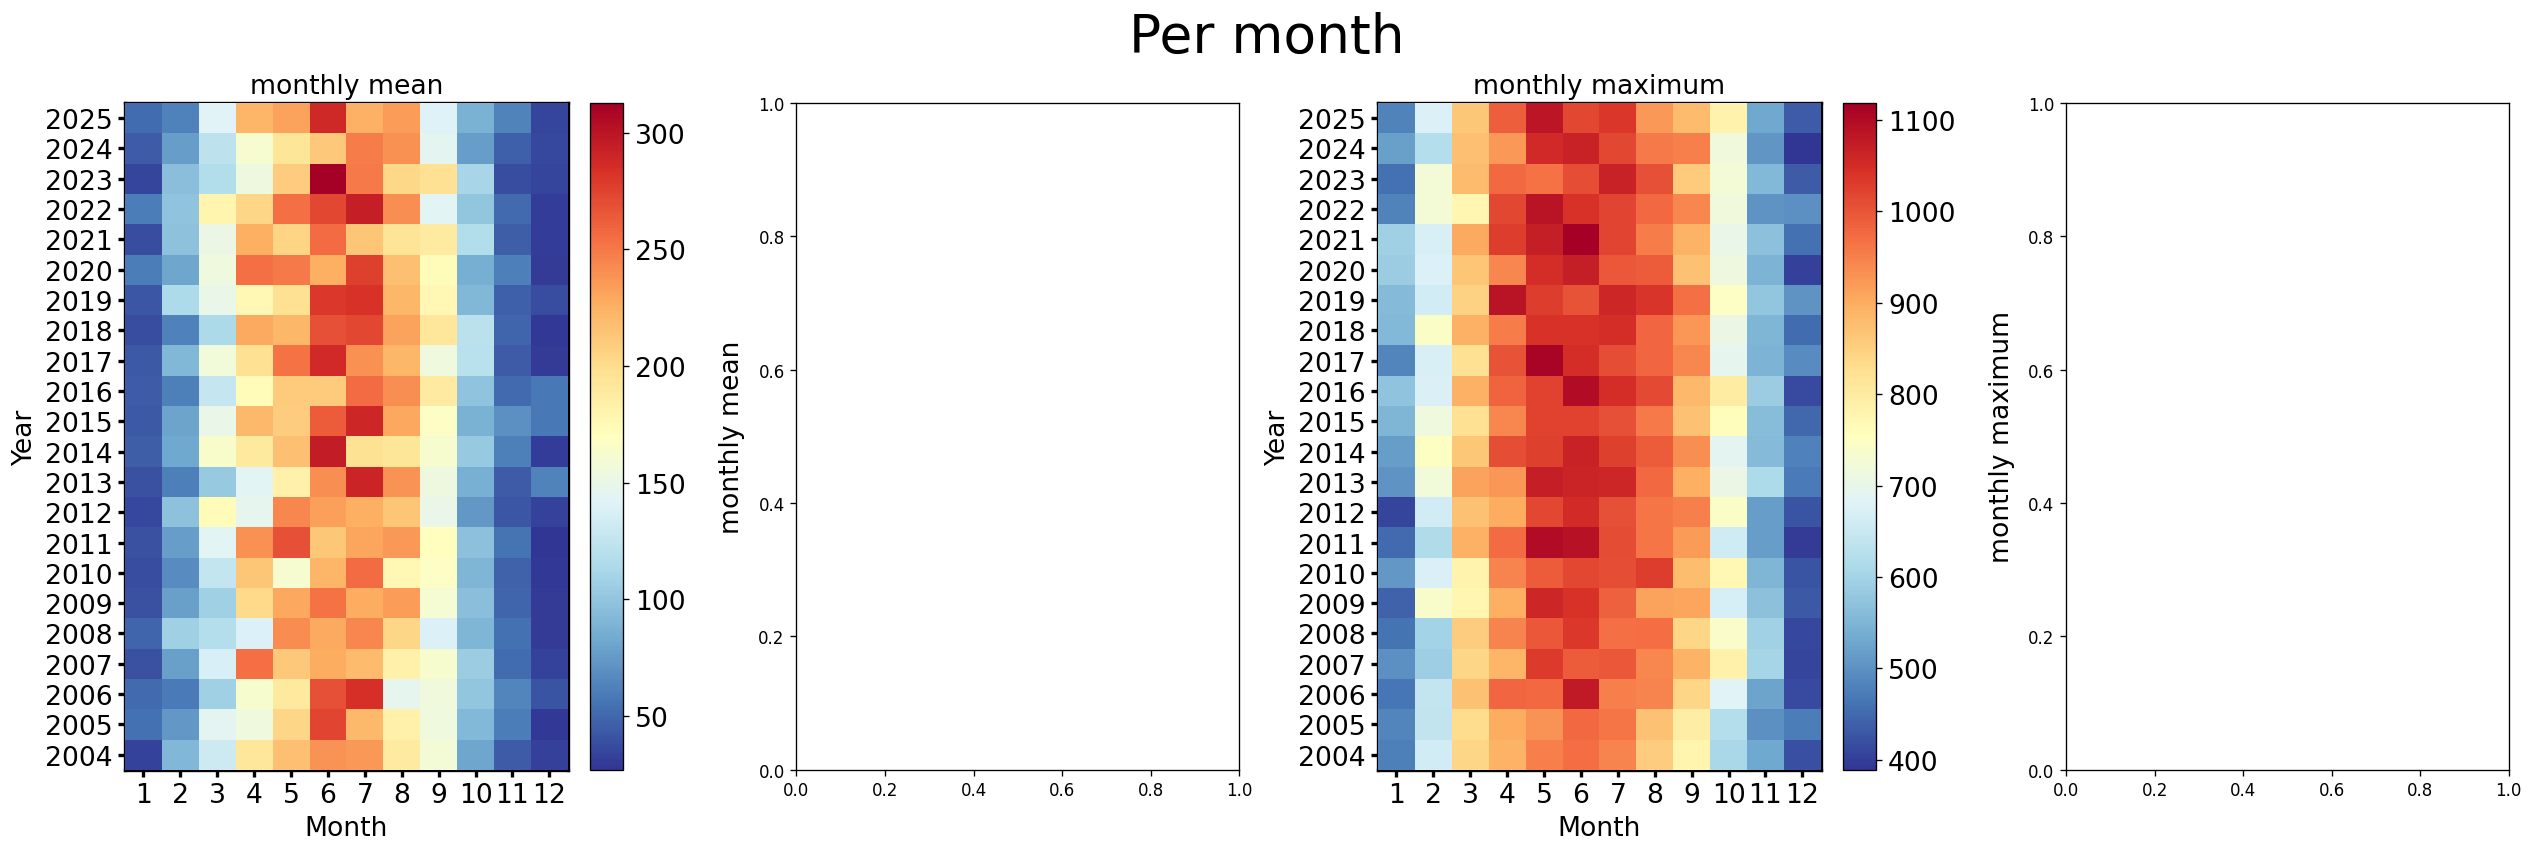

In [17]:
fig, axs = plt.subplots(ncols=4, figsize=(21, 7), dpi=120, layout="constrained")
fig.suptitle(f'Per month', fontsize=32)
dv.heatmapyearmonth(series=series, title="monthly mean", agg='mean', ax=axs[0], cb_digits_after_comma=0, zlabel="monthly mean").plot()
# dv.heatmapyearmonth(series=series, title="monthly minimum", agg='min', ax=axs[1], cb_digits_after_comma=0, zlabel="monthly minimum").plot()
dv.heatmapyearmonth(series=series, title="monthly maximum", agg='max', ax=axs[2], cb_digits_after_comma=0, zlabel="monthly maximum").plot()
# _range = series.resample('M').max().sub(series.resample('M').min())
# dv.heatmapyearmonth(series=_range, title="monthly range", ax=axs[3], cb_digits_after_comma=0, zlabel="monthly range").plot()

## Monthly ranks

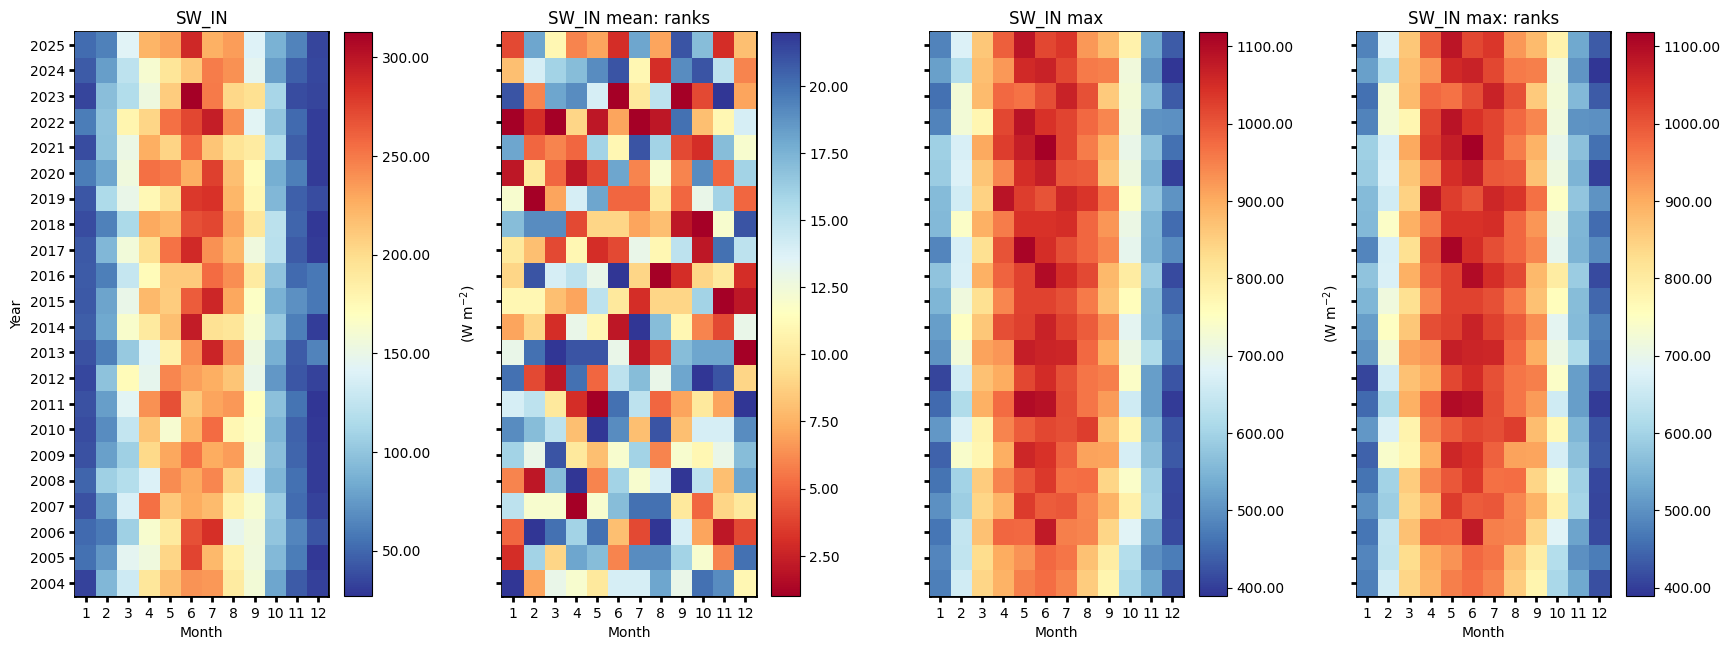

In [22]:
# Figure
fig = plt.figure(facecolor='white', figsize=(17, 6))

# Gridspec for layout
gs = gridspec.GridSpec(1, 4)  # rows, cols
gs.update(wspace=0.35, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean_ranks = fig.add_subplot(gs[0, 1])
ax_max = fig.add_subplot(gs[0, 2])
ax_max_ranks = fig.add_subplot(gs[0, 3])
params = {'axlabels_fontsize': 10, 'ticks_labelsize': 10, 'cb_labelsize': 10}
dv.heatmapyearmonth(ax=ax_mean, series=series, agg='mean', ranks=False, zlabel=f"{units}", cmap="RdYlBu_r", show_values=False, **params).plot()

hm_mean_ranks = dv.heatmapyearmonth(ax=ax_mean_ranks, series=series, agg='mean', ranks=True, **params)
hm_mean_ranks.plot()

dv.heatmapyearmonth(ax=ax_max, series=series, agg='max', ranks=False, zlabel=f"{units}", cmap="RdYlBu_r", show_values=False, **params).plot()
dv.heatmapyearmonth(ax=ax_max_ranks, series=series, agg='max', **params).plot()

ax_mean.set_title(f"{var}", color='black')
ax_mean_ranks.set_title(f"{var} mean: ranks", color='black')
ax_max.set_title(f"{var} max", color='black')
ax_max_ranks.set_title(f"{var} max: ranks", color='black')

ax_mean.tick_params(left=True, right=False, top=False, bottom=True,
                    labelleft=True, labelright=False, labeltop=False, labelbottom=True)
ax_mean_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                   labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)

ax_mean_ranks.set_ylabel("")
ax_max.set_ylabel("")
ax_max_ranks.set_ylabel("")

fig.show()

### Mean ranks per year

In [ ]:
hm_mean_ranks.hm.get_plot_data().mean(axis=1).plot(title="Mean ranks per year");

</br>

# Ridgeline plots

## Yearly

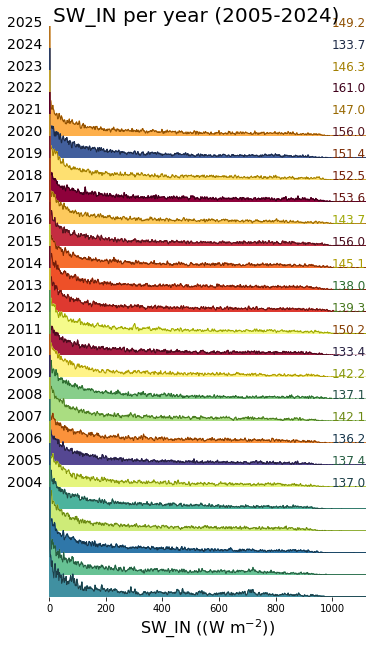

In [23]:
rp = dv.ridgeline(series=series)
rp.plot(
    how='yearly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.01],  # min/max as list
    hspace=-0.8,  # overlap between months
    xlabel=f"{var} ({units})",
    fig_width=5,
    fig_height=9,
    shade_percentile=0.5,
    show_mean_line=False,
    fig_title=f"{var} per year (2005-2024)",
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Monthly

In [ ]:
# rp.plot(
#     how='monthly',
#     kd_kwargs=None,  # params from scikit KernelDensity as dict
#     xlim=xlim,  # min/max as list
#     ylim=[0, 0.01],  # min/max as list
#     hspace=-0.6,  # overlap between months
#     xlabel=f"{var} ({units})",
#     fig_width=4.5,
#     fig_height=8,
#     shade_percentile=0.5,
#     show_mean_line=False,
#     fig_title=f"{var} per month (2005-2024)",
#     fig_dpi=72,
#     showplot=True,
#     ascending=False
# )

## Weekly

In [ ]:
# rp.plot(
#     how='weekly',
#     kd_kwargs=None,  # params from scikit KernelDensity as dict
#     xlim=xlim,  # min/max as list
#     ylim=[0, 0.15],  # min/max as list
#     hspace=-0.6,  # overlap
#     xlabel=f"{var} ({units})",
#     fig_width=6,
#     fig_height=16,
#     shade_percentile=0.5,
#     show_mean_line=False,
#     fig_title=f"{var} per week (2005-2024)",
#     fig_dpi=72,
#     showplot=True,
#     ascending=False
# )

## Single years per month

In [ ]:
# uniq_years = series.index.year.unique()
# for uy in uniq_years:
#     series_yr = series.loc[series.index.year == uy].copy()
#     rp = dv.ridgeline(series=series_yr)
#     rp.plot(
#         how='monthly',
#         kd_kwargs=None,  # params from scikit KernelDensity as dict
#         xlim=xlim,  # min/max as list
#         ylim=[0, 0.18],  # min/max as list
#         hspace=-0.6,  # overlap
#         xlabel=f"{var} ({units})",
#         fig_width=6,
#         fig_height=7,
#         shade_percentile=0.5,
#         show_mean_line=False,
#         fig_title=f"{var} per month ({uy})",
#         fig_dpi=72,
#         showplot=True,
#         ascending=False
#     )

## Single years per week

In [ ]:
# uniq_years = series.index.year.unique()
# for uy in uniq_years:
#     series_yr = series.loc[series.index.year == uy].copy()
#     rp = dv.ridgeline(series=series_yr)
#     rp.plot(
#         how='weekly',
#         kd_kwargs=None,  # params from scikit KernelDensity as dict
#         xlim=xlim,  # min/max as list
#         ylim=[0, 0.3],  # min/max as list
#         hspace=-0.8,  # overlap
#         xlabel=f"{var} ({units})",
#         fig_width=9,
#         fig_height=18,
#         shade_percentile=0.5,
#         show_mean_line=False,
#         fig_title=f"{var} per week ({uy})",
#         fig_dpi=72,
#         showplot=True,
#         ascending=False
#     )

</br>

# Cumulative plot

In [ ]:
CumulativeYear(
    series=series,
    series_units=units,
    start_year=2005,
    end_year=2024,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=2024,
    highlight_year_color='#F44336').plot();

</br>

# Long-term anomalies

In [ ]:
series_yearly_mean = series.resample('YE').mean()
series_yearly_mean.index = series_yearly_mean.index.year
series_label = f"CH-CHA: {varname}"
LongtermAnomaliesYear(series=series_yearly_mean,
                      series_label=series_label,
                      series_units=units,
                      reference_start_year=2005,
                      reference_end_year=2024).plot()

</br>

# End of notebook

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")